Cloning into 'GreenPulse'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 63 (delta 22), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 15.22 MiB | 17.81 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 534M/534M [00:19<00:00, 28.5MB/s]

Extracting files...


/kaggle/input/plantvillage-dataset
/root/.cache/kagglehub/datasets/karagwaanntreasure/plant-disease-detection/versions/1
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 1.01G/1.01G [01:10<00:00, 15.5MB/s]

Extracting files...


Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Cocoa_Pod_Borer: 103 unique images
  └─ Maize_Common_Rust: 2144 unique images
  └─ Tomato_Early_Blight: 1000 unique images
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Tomato_Leaf_Mold: 952 unique images
  └─ Cocoa_Healthy: 3344 unique images
  └─ Cocoa_Black_Pod_Rot: 943 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Tomato_Healthy: 1585 unique images


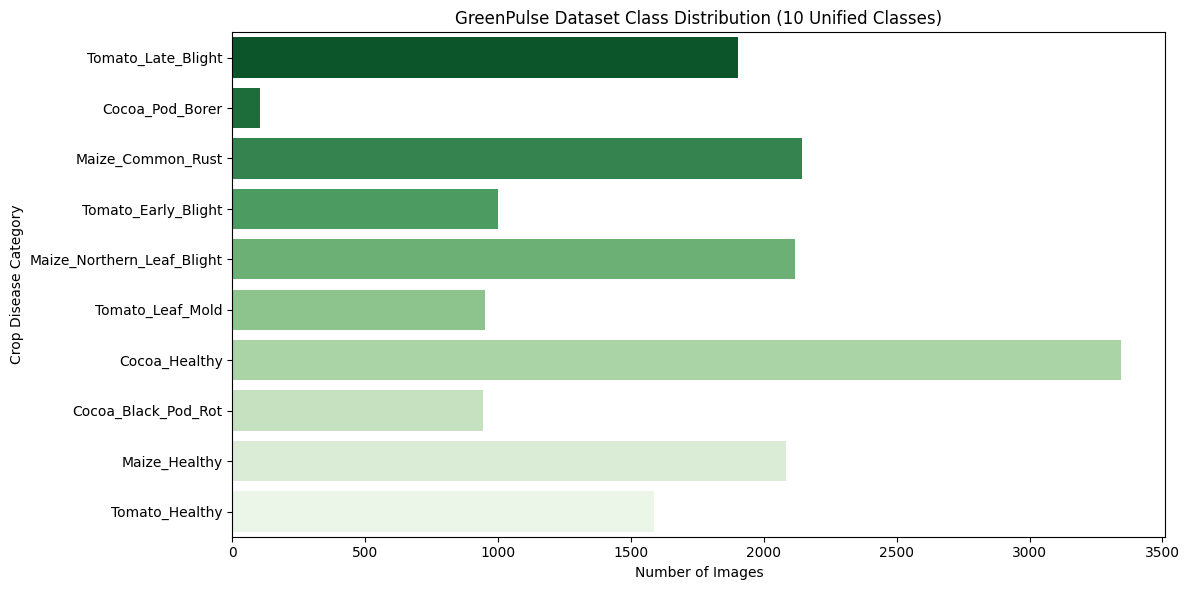

CUDA available: True
GPU: Tesla T4
True
Using device: cuda
GPU: Tesla T4
['Cocoa_Black_Pod_Rot', 'Cocoa_Healthy', 'Cocoa_Pod_Borer', 'Maize_Common_Rust', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold']
16172
Train: 11320
Validation: 2425
Test: 2427
Training images: 11320
Validation images: 2425
Test images: 2427
Training batches: 354
Validation batches: 76
Test batches: 76


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([32, 3, 224, 224])
torch.Size([32])
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 64.7MB/s]


Trainable parameters:
 classifier.0.weight
 classifier.0.bias
 classifier.3.weight
 classifier.3.bias
Epoch  1/5 | train loss 0.675 acc 0.837 | val loss 0.258 acc 0.926
Epoch  2/5 | train loss 0.230 acc 0.932 | val loss 0.176 acc 0.945
Epoch  3/5 | train loss 0.176 acc 0.944 | val loss 0.152 acc 0.952
Epoch  4/5 | train loss 0.150 acc 0.948 | val loss 0.145 acc 0.953
Epoch  5/5 | train loss 0.135 acc 0.955 | val loss 0.137 acc 0.953
{'train_loss': [0.6751507770256946, 0.22981575283060646, 0.17558559726910541, 0.15012383614749034, 0.13499771614588613], 'train_acc': [0.8368374558303887, 0.9324204946996466, 0.9440812720848056, 0.948321554770318, 0.9546819787985866], 'val_loss': [0.25821646553339417, 0.1760954371893529, 0.1522813399520117, 0.14513828057142877, 0.13733614457636764], 'val_acc': [0.9257731958762887, 0.9451546391752578, 0.9521649484536082, 0.9529896907216495, 0.9529896907216495]}
True
Model size: 16.28 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
%run notebooks/00_data_exploration_and_cleaning.ipynb
%run notebooks/01_model_training.ipynb

In [7]:
import torch
import numpy as numpy
import matplotlib.pyplot as plt

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device: ", device)

Using device:  cuda


In [12]:
import torch
import torch.nn as nn
from torchvision import models

#Loading the saved model weights
checkpoint = torch.load( "models/crop_disease_model.pth",map_location = device)

model = models.mobilenet_v3_large(weights=None)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    10
)


model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [13]:
all_labels = []
all_predictions = []

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

print("True labels:", len(all_labels))
print("Predictions:", len(all_predictions))

True labels: 2427
Predictions: 2427


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1 Score:      {f1:.4f}")

Test Accuracy: 95.92%
Precision:     0.9580
Recall:        0.9592
F1 Score:      0.9581


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1 Score:      {f1:.4f}")

Test Accuracy: 95.92%
Precision:     0.9580
Recall:        0.9592
F1 Score:      0.9581


In [16]:
from sklearn.metrics import classification_report

class_names = [
    'Cocoa_Black_Pod_Rot',
    'Cocoa_Healthy',
    'Cocoa_Pod_Borer',
    'Maize_Common_Rust',
    'Maize_Healthy',
    'Maize_Northern_Leaf_Blight',
    'Tomato_Early_Blight',
    'Tomato_Healthy',
    'Tomato_Late_Blight',
    'Tomato_Leaf_Mold'
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.80      0.67      0.73       144
             Cocoa_Healthy       0.91      0.96      0.94       509
           Cocoa_Pod_Borer       0.62      0.53      0.57        15
         Maize_Common_Rust       1.00      1.00      1.00       320
             Maize_Healthy       1.00      1.00      1.00       301
Maize_Northern_Leaf_Blight       1.00      1.00      1.00       298
       Tomato_Early_Blight       0.94      0.94      0.94       143
            Tomato_Healthy       1.00      1.00      1.00       241
        Tomato_Late_Blight       0.98      0.96      0.97       282
          Tomato_Leaf_Mold       0.95      0.98      0.97       174

                  accuracy                           0.96      2427
                 macro avg       0.92      0.90      0.91      2427
              weighted avg       0.96      0.96      0.96      2427



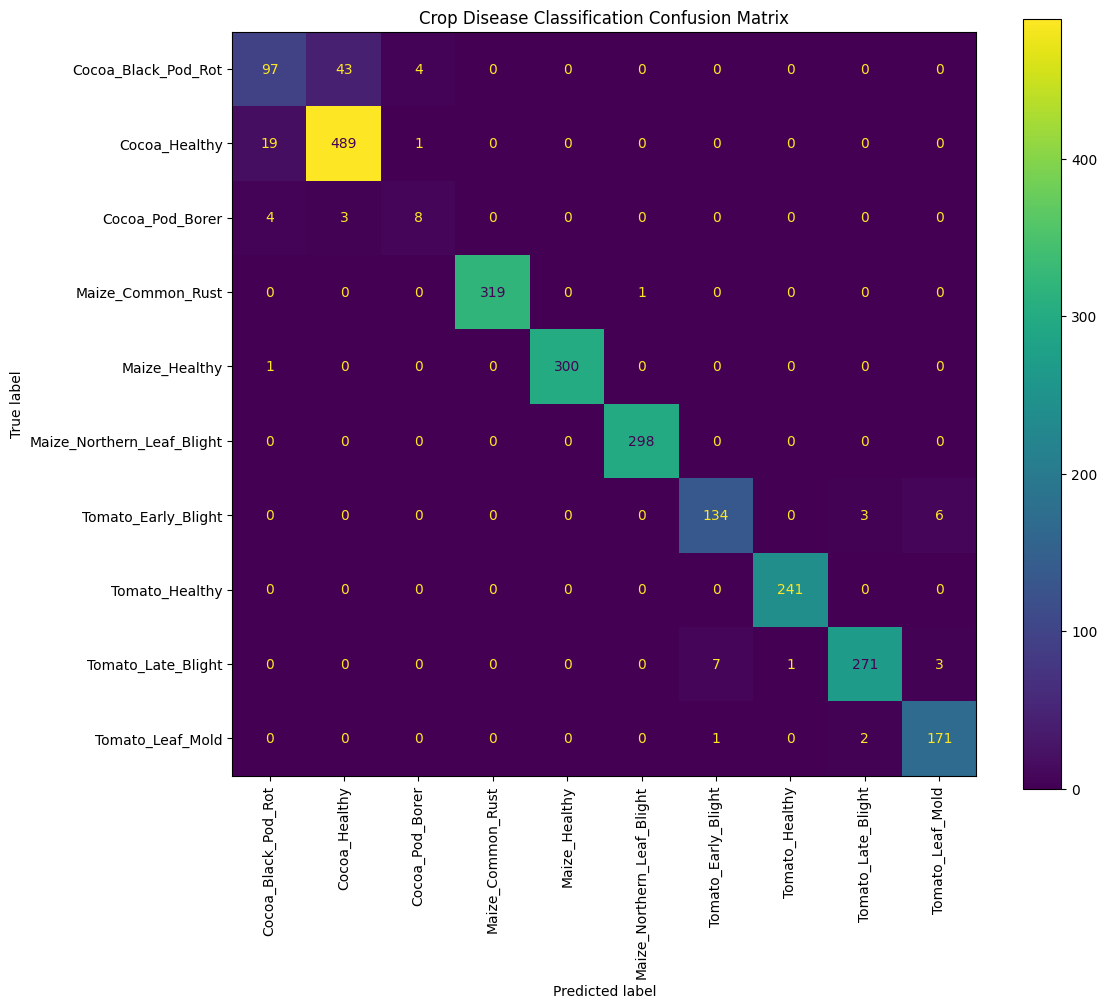

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Crop Disease Classification Confusion Matrix")
plt.show()

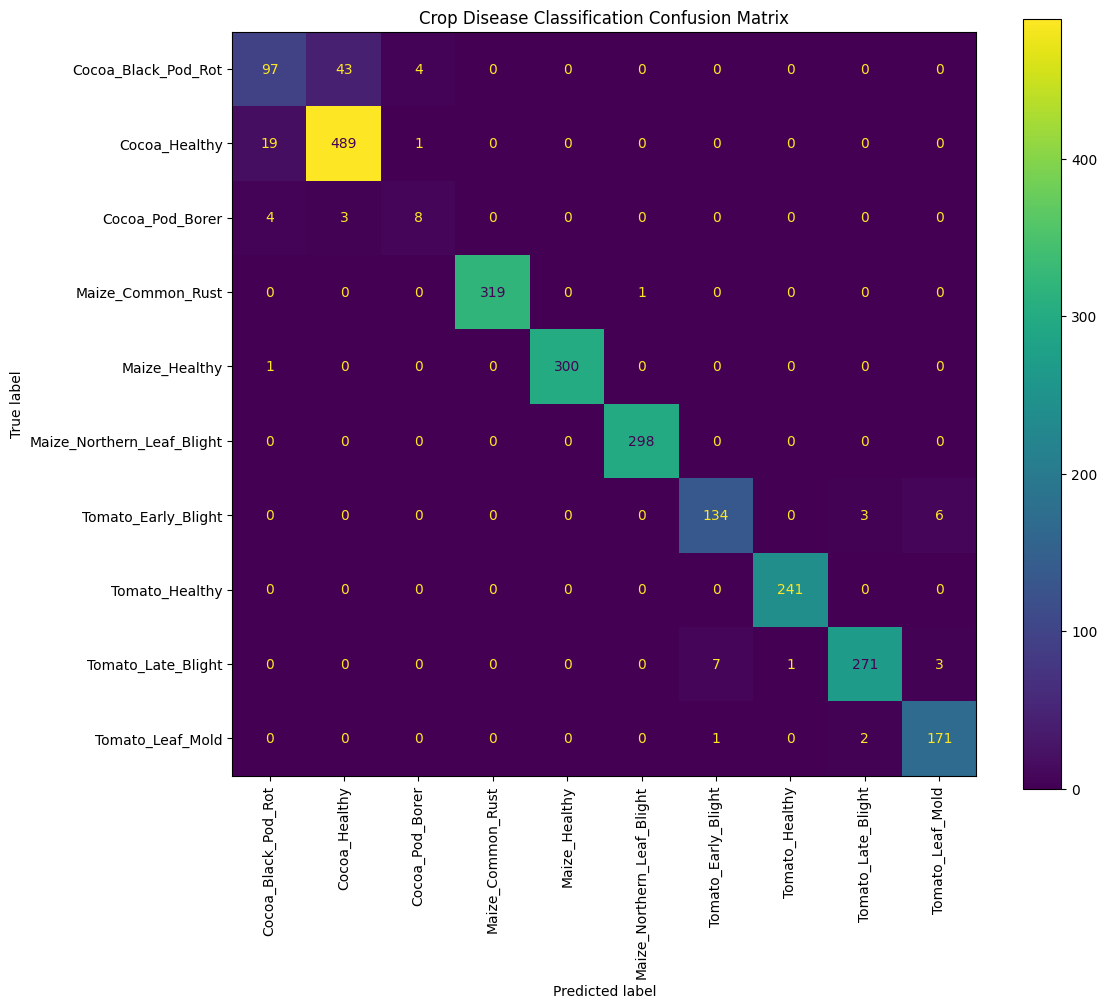

In [18]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    ax = ax,
    xticks_rotation=90
)

plt.title("Crop Disease Classification Confusion Matrix")
plt.show()

Confusion Matrix Analysis
The confusion matrix shows that the MobileNetV3 model performs particularly well on the maize and tomato classes. Maize Northern Leaf Blight and Tomato Healthu were classified correctly for all test samples, while very few errors occurred among the other maize classes.Of the 144 Cocoa Black Pod Rot images, 43 images were incorrectly classified as Cocoa Healthy. Cocoa Pod Borer was also challenging, with only 8 of 15 test samples correctly identified. This may partly result from class imbalance because Cocoa Pod Borer has substantially fewer samples than the other disease categories.These results indicate that improving the model's performance on unreppresented cocoa diseases should be a focus of further tuning.  

##Training and Validation Performance Analysis

In [20]:
history = {
    "train_loss": [
        0.6815555452879242,
        0.2312959857521967,
        0.17782312015551982,
        0.14987477635958169,
        0.13809144177306246
    ],

    "train_acc": [
        0.8360424028268552,
        0.9326855123674912,
        0.9412544169611308,
        0.9507950530035336,
        0.9539752650176678
    ],

    "val_loss": [
        0.2667954191104653,
        0.1829991599948136,
        0.15479528693501482,
        0.15019116851318742,
        0.13896452529605516
    ],

    "val_acc": [
        0.9204123711340206,
        0.9385567010309278,
        0.9488659793814433,
        0.9472164948453609,
        0.9554639175257732
    ]
}

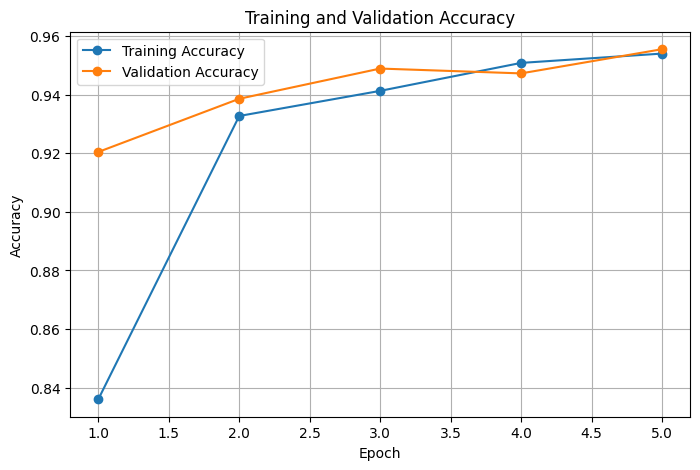

In [21]:
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

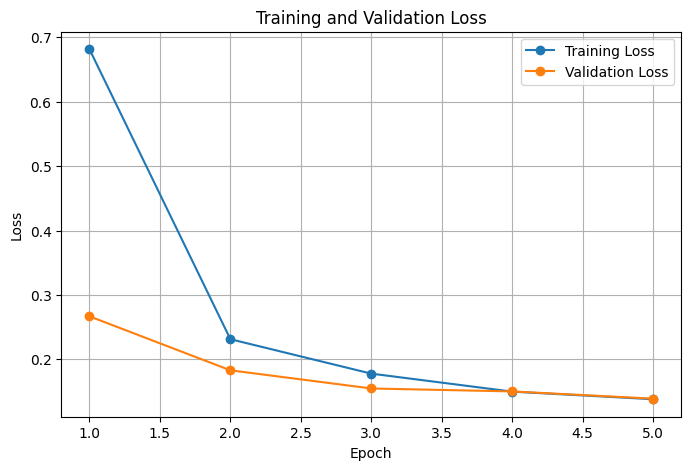

In [23]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

**Training Analysis:***
Both training and validation performance improved steadily across the five epochs.
Training accuracy increased from approximately 83.6% to 95.4%, while validation accuracy increased from approximately 92.0% to 95.5%. At the same time, both training and validation loss decreased. The relatively small difference between training and validation performance suggests that the model did not show significant overfitting during training. The final validation accuracy was also consistent with the 96% accuracy obtained on the test set.

In [24]:
from collections import Counter

train_targets = [
    train_ds.dataset.targets[i]
    for i in train_ds.indices
]

class_counts = Counter(train_targets)

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {class_counts[i]}"
    )

Cocoa_Black_Pod_Rot: 644
Cocoa_Healthy: 2318
Cocoa_Pod_Borer: 70
Maize_Common_Rust: 1514
Maize_Healthy: 1457
Maize_Northern_Leaf_Blight: 1501
Tomato_Early_Blight: 722
Tomato_Healthy: 1110
Tomato_Late_Blight: 1331
Tomato_Leaf_Mold: 653


In [25]:
counts = torch.tensor(
    [
        class_counts[i]
        for i in range(len(class_names))
    ],
    dtype=torch.float
)

class_weights = counts.sum() / (
    len(counts) * counts
)

print(class_weights)

tensor([ 1.7578,  0.4884, 16.1714,  0.7477,  0.7769,  0.7542,  1.5679,  1.0198,
         0.8505,  1.7335])


In [26]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = len(class_names)

# Start from the same pretrained MobileNetV3 Large
weights = models.MobileNet_V3_Large_Weights.DEFAULT

weighted_model = models.mobilenet_v3_large(
    weights=weights
)

# Freeze all layers first
for param in weighted_model.parameters():
    param.requires_grad = False

# Replace final classification layer
weighted_model.classifier[3] = nn.Linear(
    weighted_model.classifier[3].in_features,
    num_classes
)

for param in weighted_model.classifier.parameters():
    param.requires_grad = True

weighted_model = weighted_model.to(device)

print("Trainable parameters:")

for name, param in weighted_model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable parameters:
classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias


In [29]:
weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)
weighted_optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        weighted_model.parameters()
    ),
    lr=1e-4
)
num_epochs = 5

weighted_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):


    # TRAINING

    weighted_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        weighted_optimizer.zero_grad()

        outputs = weighted_model(images)

        loss = weighted_criterion(
            outputs,
            labels
        )

        loss.backward()

        weighted_optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predictions = torch.max(
            outputs,
            1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    train_loss /= train_total

    train_accuracy = (
        train_correct / train_total
    )



    # VALIDATION

    weighted_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.inference_mode():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = weighted_model(images)

            loss = weighted_criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * images.size(0)
            )

            _, predictions = torch.max(
                outputs,
                1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss /= val_total

    val_accuracy = (
        val_correct / val_total
    )


    weighted_history["train_loss"].append(
        train_loss
    )

    weighted_history["train_acc"].append(
        train_accuracy
    )

    weighted_history["val_loss"].append(
        val_loss
    )

    weighted_history["val_acc"].append(
        val_accuracy
    )


    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"train loss {train_loss:.3f} "
        f"acc {train_accuracy:.3f} | "
        f"val loss {val_loss:.3f} "
        f"acc {val_accuracy:.3f}"
    )


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch  1/5 | train loss 0.863 acc 0.830 | val loss 0.346 acc 0.922
Epoch  2/5 | train loss 0.319 acc 0.913 | val loss 0.253 acc 0.936
Epoch  3/5 | train loss 0.243 acc 0.928 | val loss 0.217 acc 0.940
Epoch  4/5 | train loss 0.207 acc 0.932 | val loss 0.196 acc 0.939
Epoch  5/5 | train loss 0.186 acc 0.939 | val loss 0.189 acc 0.922


In [30]:
val_labels = []
val_predictions = []

weighted_model.eval()

with torch.inference_mode():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = weighted_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        val_labels.extend(
            labels.cpu().numpy()
        )

        val_predictions.extend(
            predictions.cpu().numpy()
        )

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

weighted_val_accuracy = accuracy_score(
    val_labels,
    val_predictions
)

weighted_macro_f1 = f1_score(
    val_labels,
    val_predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    val_labels,
    val_predictions,
    average="weighted",
    zero_division=0
)

print(f"Validation Accuracy: {weighted_val_accuracy:.4f}")
print(f"Macro F1:            {weighted_macro_f1:.4f}")
print(f"Weighted F1:         {weighted_f1:.4f}")

print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Validation Accuracy: 0.9221
Macro F1:            0.8877
Weighted F1:         0.9266
                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.55      0.86      0.67       155
             Cocoa_Healthy       0.96      0.76      0.85       517
           Cocoa_Pod_Borer       0.43      0.89      0.58        18
         Maize_Common_Rust       0.99      0.99      0.99       310
             Maize_Healthy       1.00      1.00      1.00       326
Maize_Northern_Leaf_Blight       0.99      0.98      0.99       317
       Tomato_Early_Blight       0.91      0.93      0.92       135
            Tomato_Healthy       1.00      0.99      1.00       234
        Tomato_Late_Blight       0.96      0.94      0.95       288
          Tomato_Leaf_Mold       0.92      0.96      0.94       125

                  accuracy                           0.92      2425
                 macro avg       0.87      0.93      0.89      2425
              weighted avg    

In [32]:
baseline_val_labels = []
baseline_val_predictions = []

model.eval()

with torch.inference_mode():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        baseline_val_labels.extend(
            labels.cpu().numpy()
        )

        baseline_val_predictions.extend(
            predictions.cpu().numpy()
        )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [33]:
baseline_val_accuracy = accuracy_score(
    baseline_val_labels,
    baseline_val_predictions
)

baseline_macro_f1 = f1_score(
    baseline_val_labels,
    baseline_val_predictions,
    average="macro",
    zero_division=0
)

baseline_weighted_f1 = f1_score(
    baseline_val_labels,
    baseline_val_predictions,
    average="weighted",
    zero_division=0
)

print(
    f"Baseline Validation Accuracy: "
    f"{baseline_val_accuracy:.4f}"
)

print(
    f"Baseline Macro F1: "
    f"{baseline_macro_f1:.4f}"
)

print(
    f"Baseline Weighted F1: "
    f"{baseline_weighted_f1:.4f}"
)

print(
    classification_report(
        baseline_val_labels,
        baseline_val_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Baseline Validation Accuracy: 0.9596
Baseline Macro F1: 0.9221
Baseline Weighted F1: 0.9586
                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.87      0.70      0.78       155
             Cocoa_Healthy       0.92      0.97      0.94       517
           Cocoa_Pod_Borer       0.67      0.67      0.67        18
         Maize_Common_Rust       1.00      0.99      0.99       310
             Maize_Healthy       1.00      1.00      1.00       326
Maize_Northern_Leaf_Blight       0.99      0.99      0.99       317
       Tomato_Early_Blight       0.97      0.93      0.95       135
            Tomato_Healthy       1.00      1.00      1.00       234
        Tomato_Late_Blight       0.97      0.96      0.97       288
          Tomato_Leaf_Mold       0.91      0.98      0.94       125

                  accuracy                           0.96      2425
                 macro avg       0.93      0.92      0.92      2425
              weighted

A class-weighted loss function was tested to address the imbalance observed in the cocoa disease classes. Although weighting increased the recall of minority classes such as Cocoa Pod Borer from 0.67 to 0.89, its precision decreased from 0.67 to 0.43. Consequently, the Cocoa Pod Borer F1-score decreased from 0.67 to 0.58. Overall validation accuracy also decreased from 95.96% for the baseline model to 92.21% for the weighted model. The baseline MobileNetV3 model therefore provided a better balance between overall and per-class performance.

In [34]:
mild_weights = torch.sqrt(class_weights)
print(mild_weights)

tensor([1.3258, 0.6988, 4.0214, 0.8647, 0.8814, 0.8684, 1.2521, 1.0099, 0.9222,
        1.3166])


In [35]:
from torchvision import models
import torch.nn as nn

num_classes = len(class_names)

weights = models.MobileNet_V3_Large_Weights.DEFAULT

mild_model = models.mobilenet_v3_large(
    weights=weights
)

# Freeze all parameters
for param in mild_model.parameters():
    param.requires_grad = False

# Replace final layer
mild_model.classifier[3] = nn.Linear(
    mild_model.classifier[3].in_features,
    num_classes
)

# Make classifier trainable
for param in mild_model.classifier.parameters():
    param.requires_grad = True

mild_model = mild_model.to(device)

In [36]:
mild_criterion = nn.CrossEntropyLoss(
    weight=mild_weights.to(device)
)

In [37]:
mild_optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        mild_model.parameters()
    ),
    lr=1e-4
)

In [38]:
num_epochs = 5

mild_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    mild_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        mild_optimizer.zero_grad()

        outputs = mild_model(images)

        loss = mild_criterion(
            outputs,
            labels
        )

        loss.backward()
        mild_optimizer.step()

        train_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # Validation
    mild_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.inference_mode():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = mild_model(images)

            loss = mild_criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    mild_history["train_loss"].append(train_loss)
    mild_history["train_acc"].append(train_accuracy)
    mild_history["val_loss"].append(val_loss)
    mild_history["val_acc"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"train loss {train_loss:.3f} "
        f"acc {train_accuracy:.3f} | "
        f"val loss {val_loss:.3f} "
        f"acc {val_accuracy:.3f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch  1/5 | train loss 0.766 acc 0.843 | val loss 0.304 acc 0.934
Epoch  2/5 | train loss 0.271 acc 0.931 | val loss 0.217 acc 0.934
Epoch  3/5 | train loss 0.204 acc 0.943 | val loss 0.200 acc 0.947
Epoch  4/5 | train loss 0.180 acc 0.944 | val loss 0.176 acc 0.948
Epoch  5/5 | train loss 0.160 acc 0.954 | val loss 0.174 acc 0.939


In [39]:
mild_val_labels = []
mild_val_predictions = []

mild_model.eval()

with torch.inference_mode():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = mild_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        mild_val_labels.extend(
            labels.cpu().numpy()
        )

        mild_val_predictions.extend(
            predictions.cpu().numpy()
        )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [40]:
mild_val_accuracy = accuracy_score(
    mild_val_labels,
    mild_val_predictions
)

mild_macro_f1 = f1_score(
    mild_val_labels,
    mild_val_predictions,
    average="macro",
    zero_division=0
)

mild_weighted_f1 = f1_score(
    mild_val_labels,
    mild_val_predictions,
    average="weighted",
    zero_division=0
)

print(f"Validation Accuracy: {mild_val_accuracy:.4f}")
print(f"Macro F1:            {mild_macro_f1:.4f}")
print(f"Weighted F1:         {mild_weighted_f1:.4f}")

print(
    classification_report(
        mild_val_labels,
        mild_val_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Validation Accuracy: 0.9390
Macro F1:            0.9101
Weighted F1:         0.9410
                            precision    recall  f1-score   support

       Cocoa_Black_Pod_Rot       0.62      0.83      0.71       155
             Cocoa_Healthy       0.95      0.86      0.90       517
           Cocoa_Pod_Borer       0.80      0.67      0.73        18
         Maize_Common_Rust       1.00      0.99      0.99       310
             Maize_Healthy       1.00      1.00      1.00       326
Maize_Northern_Leaf_Blight       0.99      0.99      0.99       317
       Tomato_Early_Blight       0.87      0.94      0.90       135
            Tomato_Healthy       1.00      0.99      1.00       234
        Tomato_Late_Blight       0.97      0.94      0.95       288
          Tomato_Leaf_Mold       0.93      0.92      0.92       125

                  accuracy                           0.94      2425
                 macro avg       0.91      0.91      0.91      2425
              weighted avg    

Hyperparameter Tuning and Model Comparison:
Class weighting was investigated as a method of addressing the imbalance in the training dataset, particularly for the Cocoa Pod Borer class. The first experiment used inverse-frequency class weights. Although this increased recall for the minority cocoa classes, it reduced precision and lowered overall validation accuracy to 92.21%. A second experiment used milder class weights obtained from the square root of the original weights. This improved validation accuracy to 93.90% and increased the Cocoa Pod Borer F1-score from 0.67 in the baseline model to 0.73. However, the baseline model still achieved the highest overall validation accuracy (95.96%), macro F1-score (0.9221), and weighted F1-score (0.9586). Therefore, the original MobileNetV3 model was retained as the final model because it provided the best overall balance across the disease classes.

In [41]:
final_model = model
final_model.eval()

print("Final model: Amy's baseline MobileNetV3 Large")

Final model: Amy's baseline MobileNetV3 Large


In [42]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Full Class Weights",
        "Mild Class Weights"
    ],
    "Validation Accuracy": [
        0.9596,
        0.9221,
        0.9390
    ],
    "Macro F1": [
        0.9221,
        0.8877,
        0.9101
    ],
    "Weighted F1": [
        0.9586,
        0.9266,
        0.9410
    ],
    "Cocoa Pod Borer F1": [
        0.67,
        0.58,
        0.73
    ]
})

comparison

,Model,Validation Accuracy,Macro F1,Weighted F1,Cocoa Pod Borer F1
0,Baseline,0.9596,0.9221,0.9586,0.67
1,Full Class Weights,0.9221,0.8877,0.9266,0.58
2,Mild Class Weights,0.9390,0.9101,0.9410,0.73


## Model Comparison and Final Selection

Three model configurations were evaluated. The baseline MobileNetV3
model achieved the highest validation accuracy, macro F1-score, and
weighted F1-score.

The full class-weighted model increased recall for some minority cocoa
classes but reduced precision and overall model performance. Mild class
weighting improved the Cocoa Pod Borer F1-score from 0.67 to 0.73, but
its overall validation performance remained below the baseline.

Therefore, the original MobileNetV3 model was retained as the final
model because it provided the best overall balance across the crop
disease classes.

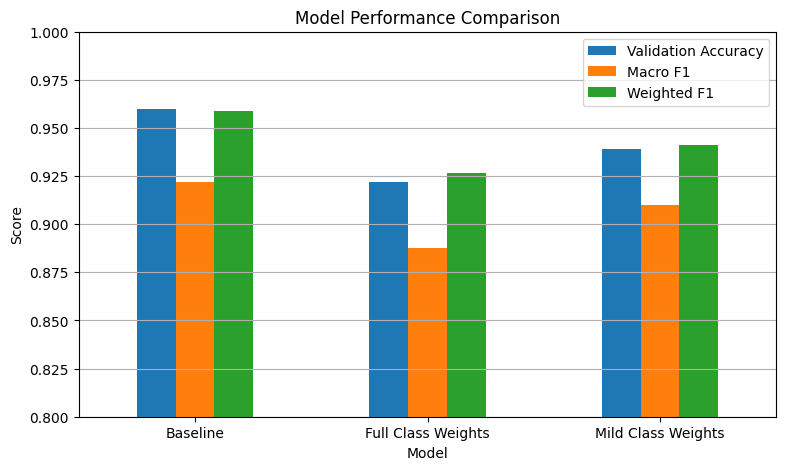

In [43]:
metrics = [
    "Validation Accuracy",
    "Macro F1",
    "Weighted F1"
]

comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")
plt.show()

## Final Observations

The baseline MobileNetV3 model achieved the strongest overall performance,
with a validation accuracy of 95.96%, a macro F1-score of 0.9221, and a
weighted F1-score of 0.9586.

The full class-weighted model reduced overall performance, although it
increased recall for some minority cocoa classes. The mild class-weighted
model performed better than the full-weighted model and improved the Cocoa
Pod Borer F1-score from 0.67 to 0.73. However, its overall validation
performance remained lower than the baseline model.

Therefore, the original baseline MobileNetV3 model was selected as the
final model because it provided the best overall balance across the crop
disease classes.

Future improvements could focus on collecting more Cocoa Pod Borer and
Cocoa Black Pod Rot images and applying targeted data augmentation to
improve performance on these underrepresented classes.

## Final Evaluation Conclusion

The baseline MobileNetV3 model was selected as the final model after
evaluation and model comparison. It achieved a test accuracy of 96.00%,
with a weighted precision of 0.9587, recall of 0.9600, and F1-score of
0.9589.

The model performed particularly well on the maize and tomato disease
classes but showed weaker performance on some cocoa disease classes.
Class weighting was investigated to address this imbalance. Although
mild weighting improved the Cocoa Pod Borer F1-score, both weighted
models produced lower overall validation performance than the baseline.

Therefore, the baseline model was retained because it provided the best
overall balance across the disease classes. Future work could focus on
collecting more cocoa disease images and applying targeted augmentation
to improve performance on underrepresented classes.